# PredictMaint — Pipeline Preditivo de Falhas Industriais

**Projeto Avaliativo — Módulo 1 · Desenvolvimento de IA para Análise Preditiva**

**Autor:** Samuel Marques  
**Dataset:** `data/manutencao_preditiva.csv`  
**Problema:** Classificação binária — prever falha mecânica em equipamentos industriais

---

### Estrutura do Notebook
| Fase | Descrição |
|---|---|
| 1 | Análise Exploratória (EDA) |
| 2 | Limpeza e Tratamento de Dados (Data Prep) |
| 3 | Feature Engineering |
| 4 | Divisão e Balanceamento dos Dados |
| 5 | Escalonamento de Variáveis (StandardScaler) |
| 6 | Ajuste de Parâmetros e Combate ao Overfitting |
| 7 | Avaliação da Acurácia e Veredito Final |
| — | Auditoria do Modelo (Model Card) |
| 8 | Random Forest *(exploratório)* |
| 9 | Boosting — XGBoost e LightGBM *(exploratório)* |
| 10 | Comparação Final Ampliada *(exploratório)* |

As Fases 1–7 são a entrega obrigatória do enunciado (comparação KNN vs Árvore de Decisão). A Auditoria e as Fases 8–10 são uma extensão exploratória, baseada no material de apoio `docs/pdf/Conhecendo Alguns Modelos de Machine Learning.pdf`, e não substituem o veredito oficial da Fase 7.

---
## Fase 1 — Análise Exploratória (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('data/manutencao_preditiva.csv')
df.head()

,udi,id_produto,tipo,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
0,1,M14860,M,298.1,308.6,1551.0,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408.0,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498.0,49.4,5,0,0,0,0,0,0
3,4,L47183,L,NaN,NaN,NaN,NaN,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408.0,40.0,9,0,0,0,0,0,0


In [2]:
print('Dimensões do dataset (linhas, colunas):', df.shape)
print('\nTipos de dados:')
print(df.dtypes)
print('\nResumo estatístico:')
df.describe()

Dimensões do dataset (linhas, colunas): (10000, 14)

Tipos de dados:
udi                          int64
id_produto                     str
tipo                           str
temperatura_ar_k           float64
temperatura_processo_k     float64
velocidade_rotacao_rpm     float64
torque_nm                  float64
desgaste_ferramenta_min      int64
falha_maquina                int64
falha_twf                    int64
falha_hdf                    int64
falha_pwf                    int64
falha_osf                    int64
falha_rnf                    int64
dtype: object

Resumo estatístico:


,udi,temperatura_ar_k,temperatura_processo_k,velocidade_rotacao_rpm,torque_nm,desgaste_ferramenta_min,falha_maquina,falha_twf,falha_hdf,falha_pwf,falha_osf,falha_rnf
count,10000.00000,9500.000000,9500.000000,9500.000000,9500.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.002158,310.000895,1539.245263,39.974168,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.001689,1.486432,180.273589,9.995453,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.100000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1504.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1613.000000,46.700000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


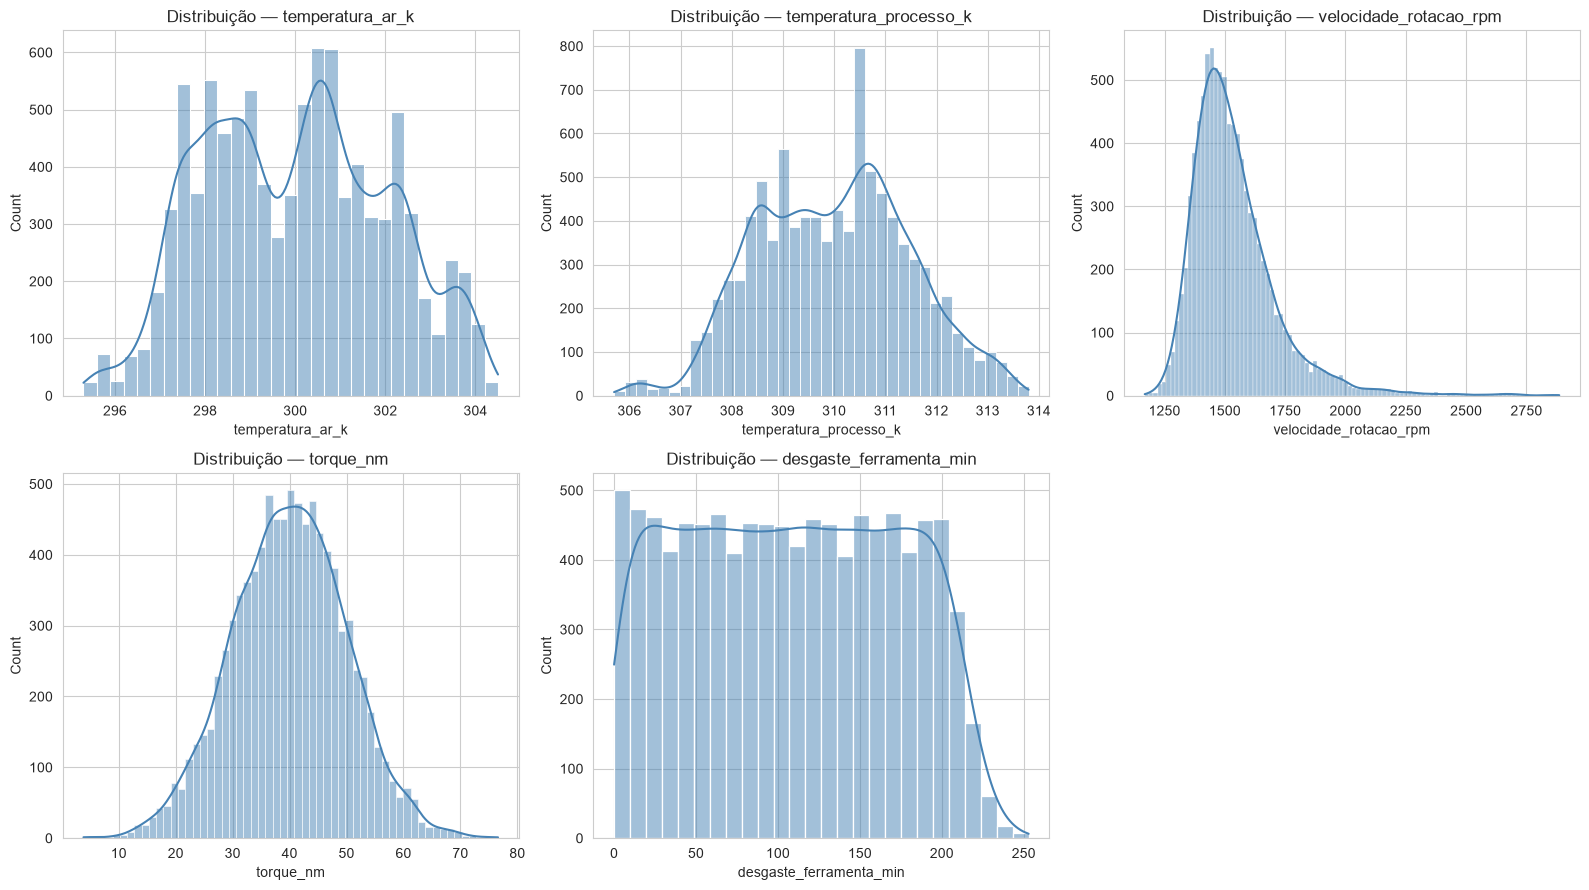

In [3]:
# Gráfico 1 — Histograma das variáveis contínuas
colunas_continuas = ['temperatura_ar_k', 'temperatura_processo_k',
                      'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(colunas_continuas):
    sns.histplot(df[col].dropna(), kde=True, ax=axes[i], color='steelblue')
    axes[i].set_title(f'Distribuição — {col}')
axes[-1].axis('off')
plt.tight_layout()
plt.savefig('outputs/graficos/01_histograma_variaveis.png')
plt.show()

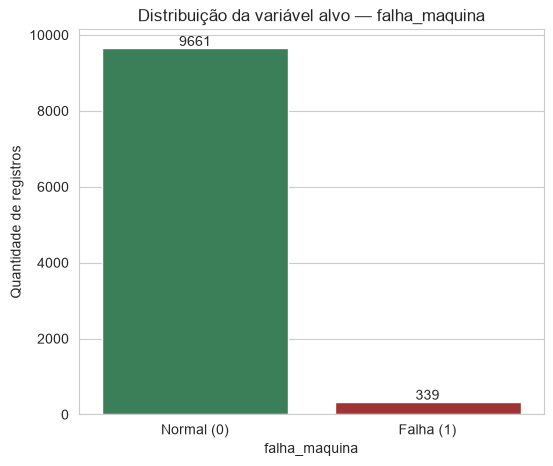

Proporção de classes:
falha_maquina
0    0.9661
1    0.0339
Name: proportion, dtype: float64


In [4]:
# Gráfico 2 — Barras da distribuição de falha_maquina
plt.figure(figsize=(6, 5))
contagem = df['falha_maquina'].value_counts()
sns.barplot(x=contagem.index, y=contagem.values, hue=contagem.index, palette=['seagreen', 'firebrick'], legend=False)
plt.xticks([0, 1], ['Normal (0)', 'Falha (1)'])
plt.ylabel('Quantidade de registros')
plt.title('Distribuição da variável alvo — falha_maquina')
for i, v in enumerate(contagem.values):
    plt.text(i, v + 50, str(v), ha='center')
plt.savefig('outputs/graficos/02_barras_falha_maquina.png')
plt.show()

print('Proporção de classes:')
print(df['falha_maquina'].value_counts(normalize=True))

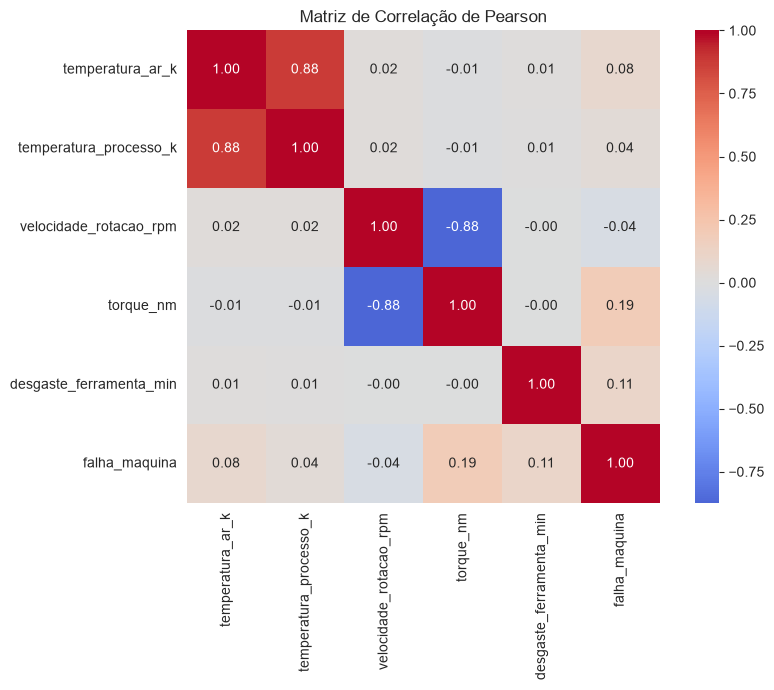

In [5]:
# Gráfico 3 — Heatmap de correlação de Pearson
plt.figure(figsize=(9, 7))
colunas_numericas = colunas_continuas + ['falha_maquina']
corr = df[colunas_numericas].corr(method='pearson')
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriz de Correlação de Pearson')
plt.tight_layout()
plt.savefig('outputs/graficos/03_heatmap_pearson.png')
plt.show()

### Análise dos padrões identificados

- A variável alvo `falha_maquina` é fortemente desbalanceada — falhas representam uma fração pequena do total, o que exige tratamento (SMOTE) antes do treino dos modelos.
- `temperatura_ar_k` e `temperatura_processo_k` têm correlação positiva forte entre si, como esperado fisicamente (uma acompanha a outra).
- `torque_nm` e `velocidade_rotacao_rpm` mostram correlação negativa — motores com maior rotação tendem a operar com menor torque, padrão típico de máquinas rotativas.
- Nenhuma variável isolada apresenta correlação linear forte com `falha_maquina`, sugerindo que a falha depende de combinações não-lineares de variáveis — favorecendo modelos como KNN e Árvore de Decisão sobre uma regressão linear simples.

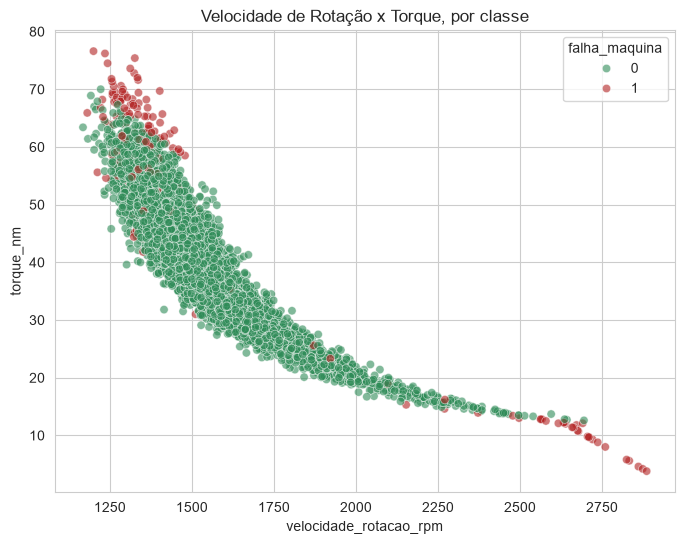

In [6]:
# Gráfico 4 — Scatter RPM x Torque por classe
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='velocidade_rotacao_rpm', y='torque_nm',
                 hue='falha_maquina', palette=['seagreen', 'firebrick'], alpha=0.6)
plt.title('Velocidade de Rotação x Torque, por classe')
plt.legend(title='falha_maquina')
plt.savefig('outputs/graficos/04_scatter_rpm_torque.png')
plt.show()

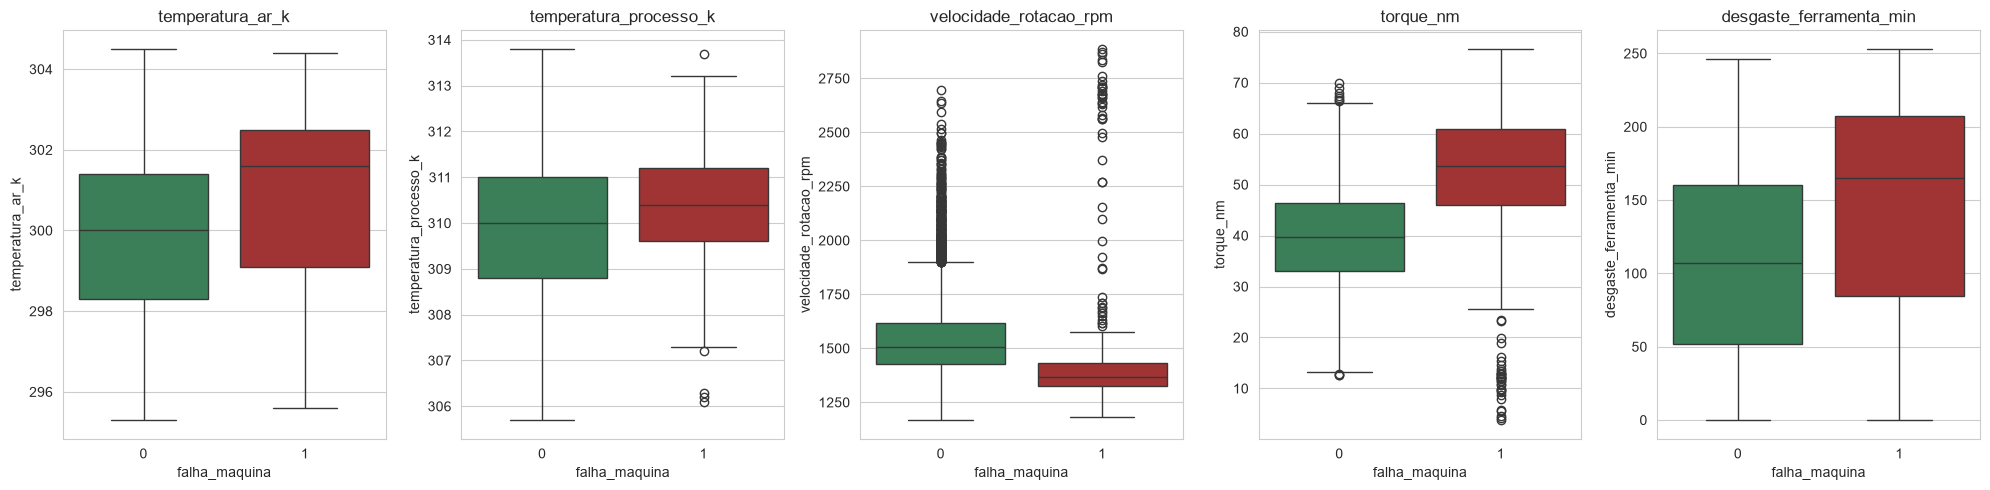

In [7]:
# Gráfico 5 — Boxplot das variáveis por classe
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(colunas_continuas):
    sns.boxplot(data=df, x='falha_maquina', y=col, hue='falha_maquina',
                palette=['seagreen', 'firebrick'], legend=False, ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('outputs/graficos/05_boxplot_por_classe.png')
plt.show()

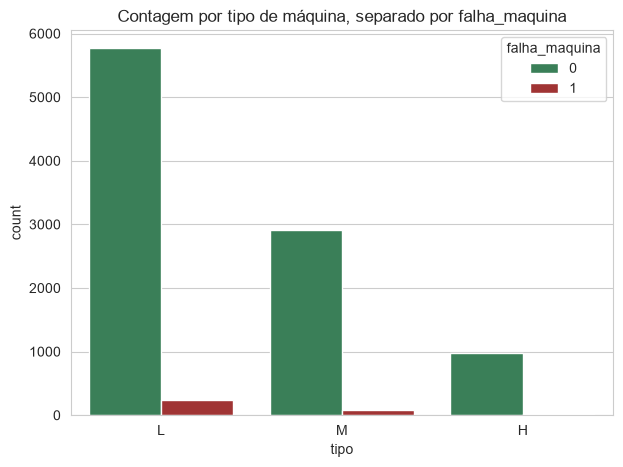

In [8]:
# Gráfico 6 — Countplot do tipo de máquina por classe
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='tipo', hue='falha_maquina', palette=['seagreen', 'firebrick'],
              order=['L', 'M', 'H'])
plt.title('Contagem por tipo de máquina, separado por falha_maquina')
plt.savefig('outputs/graficos/06_countplot_tipo.png')
plt.show()

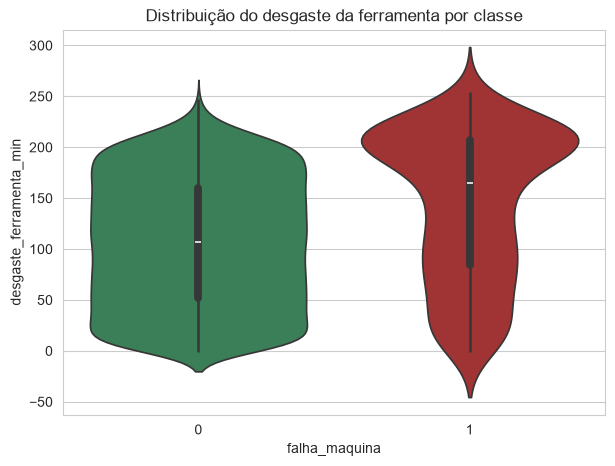

In [9]:
# Gráfico 7 — Violinplot do desgaste da ferramenta por classe
plt.figure(figsize=(7, 5))
sns.violinplot(data=df, x='falha_maquina', y='desgaste_ferramenta_min',
                hue='falha_maquina', palette=['seagreen', 'firebrick'], legend=False)
plt.title('Distribuição do desgaste da ferramenta por classe')
plt.savefig('outputs/graficos/07_violinplot_desgaste.png')
plt.show()

In [10]:
# Skewness (assimetria) das variáveis contínuas, calculada com NumPy
def skewness_numpy(serie):
    dados = serie.dropna().to_numpy()
    media = np.mean(dados)
    desvio = np.std(dados)
    return np.mean(((dados - media) / desvio) ** 3)

print('Skewness por variável (cálculo manual com NumPy):')
for col in colunas_continuas:
    print(f'  {col}: {skewness_numpy(df[col]):.4f}')

Skewness por variável (cálculo manual com NumPy):
  temperatura_ar_k: 0.1149
  temperatura_processo_k: 0.0156
  velocidade_rotacao_rpm: 1.9943
  torque_nm: -0.0079
  desgaste_ferramenta_min: 0.0273


---
## Fase 2 — Limpeza e Tratamento de Dados (Data Prep)

In [11]:
# Duplicatas
n_duplicatas = df.duplicated().sum()
print(f'Linhas duplicadas encontradas: {n_duplicatas}')

df = df.drop_duplicates().reset_index(drop=True)
print(f'Linhas duplicadas após remoção: {df.duplicated().sum()}')
print(f'Shape após remoção de duplicatas: {df.shape}')

Linhas duplicadas encontradas: 0
Linhas duplicadas após remoção: 0
Shape após remoção de duplicatas: (10000, 14)


In [12]:
# Mapeamento de valores ausentes por coluna
nan_por_coluna = df.isnull().sum()
print('Valores ausentes por coluna:')
print(nan_por_coluna[nan_por_coluna > 0])

Valores ausentes por coluna:
temperatura_ar_k          500
temperatura_processo_k    500
velocidade_rotacao_rpm    500
torque_nm                 500
dtype: int64


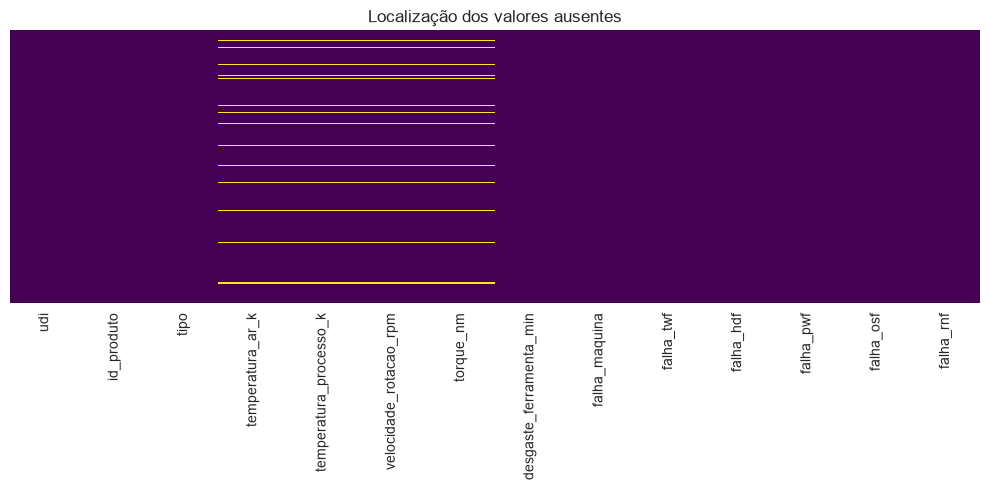

In [13]:
# Gráfico 9 — Heatmap de valores ausentes
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Localização dos valores ausentes')
plt.tight_layout()
plt.savefig('outputs/graficos/09_heatmap_nan.png')
plt.show()

In [14]:
# Skewness das colunas com NaN, para decidir entre média e mediana
colunas_com_nan = nan_por_coluna[nan_por_coluna > 0].index.tolist()

print('Skewness das colunas com valores ausentes:')
for col in colunas_com_nan:
    sk = skewness_numpy(df[col])
    estrategia = 'média' if abs(sk) < 1 else 'mediana'
    print(f'  {col}: skewness={sk:.4f} -> estratégia sugerida: {estrategia}')

Skewness das colunas com valores ausentes:
  temperatura_ar_k: skewness=0.1149 -> estratégia sugerida: média
  temperatura_processo_k: skewness=0.0156 -> estratégia sugerida: média
  velocidade_rotacao_rpm: skewness=1.9943 -> estratégia sugerida: mediana
  torque_nm: skewness=-0.0079 -> estratégia sugerida: média


In [15]:
# Imputação dos valores ausentes — média ou mediana conforme skewness
df_antes_imputacao = df[colunas_com_nan].copy()

for col in colunas_com_nan:
    sk = skewness_numpy(df[col])
    if abs(sk) < 1:
        valor = df[col].mean()
        metodo = 'média'
    else:
        valor = df[col].median()
        metodo = 'mediana'
    df[col] = df[col].fillna(valor)
    print(f'{col}: imputado com {metodo} ({valor:.2f})')

print('\nValores ausentes restantes:')
print(df.isnull().sum().sum())

temperatura_ar_k: imputado com média (300.00)
temperatura_processo_k: imputado com média (310.00)
velocidade_rotacao_rpm: imputado com mediana (1504.00)
torque_nm: imputado com média (39.97)

Valores ausentes restantes:
0


**Justificativa da imputação:** conforme a regra definida (|skewness| < 1 → distribuição aproximadamente simétrica → média; caso contrário → mediana, por ser robusta a assimetria/outliers), cada coluna com valores ausentes foi imputada com a medida de tendência central mais adequada à sua própria distribuição, evitando distorcer a variável com um valor influenciado por caudas assimétricas.

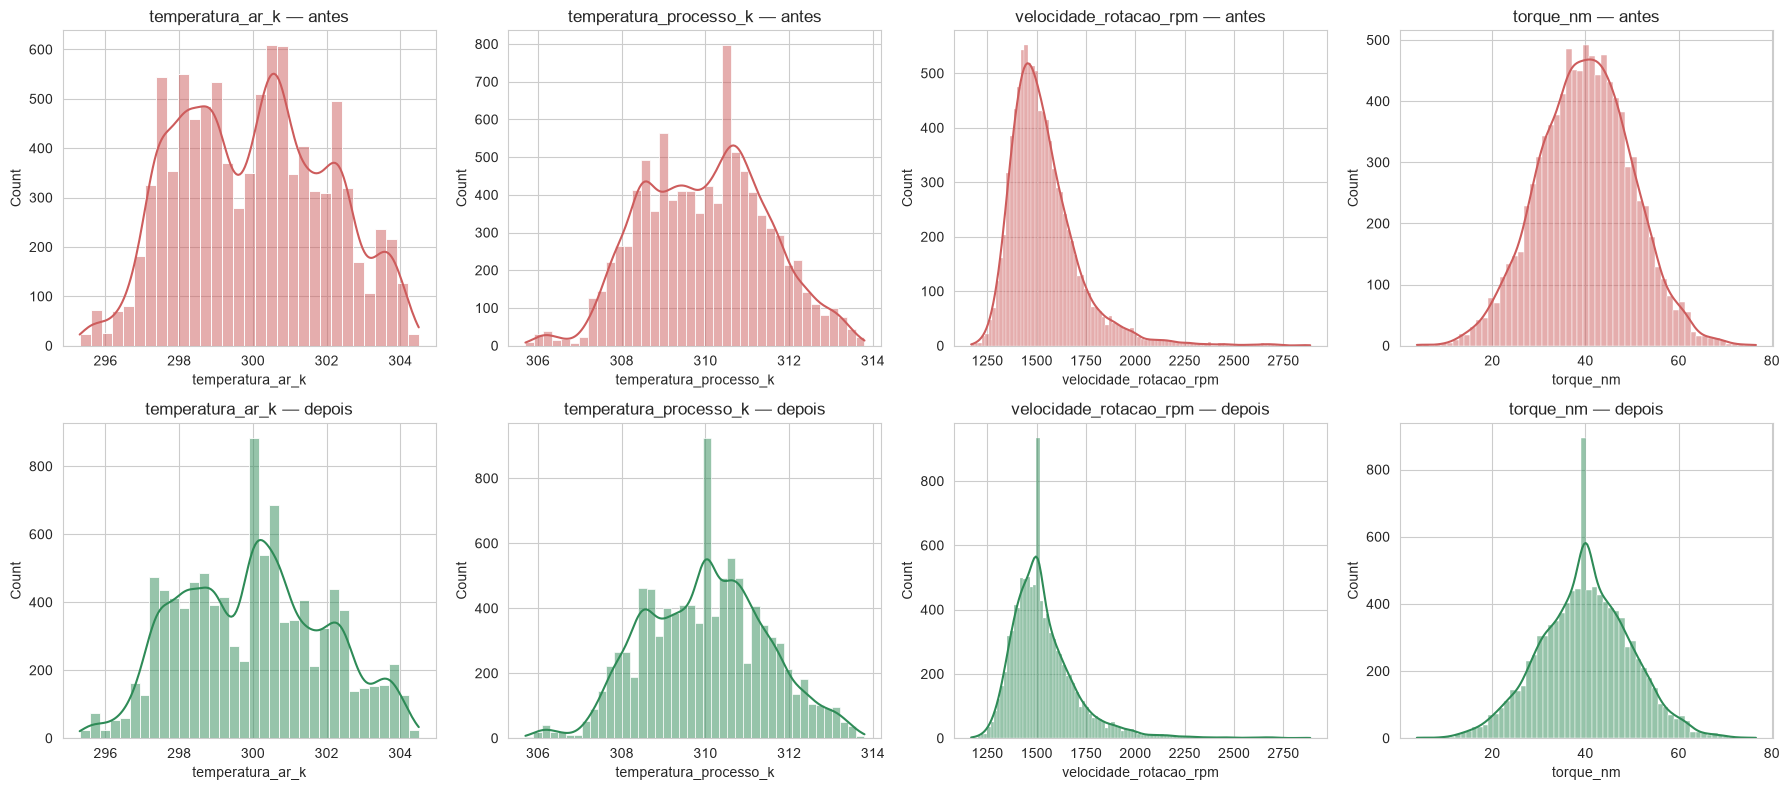

In [16]:
# Gráfico 8 — Histograma antes/depois da imputação
fig, axes = plt.subplots(2, len(colunas_com_nan), figsize=(18, 8))
for i, col in enumerate(colunas_com_nan):
    sns.histplot(df_antes_imputacao[col].dropna(), kde=True, ax=axes[0, i], color='indianred')
    axes[0, i].set_title(f'{col} — antes')
    sns.histplot(df[col], kde=True, ax=axes[1, i], color='seagreen')
    axes[1, i].set_title(f'{col} — depois')
plt.tight_layout()
plt.savefig('outputs/graficos/08_histograma_antes_depois_imputacao.png')
plt.show()

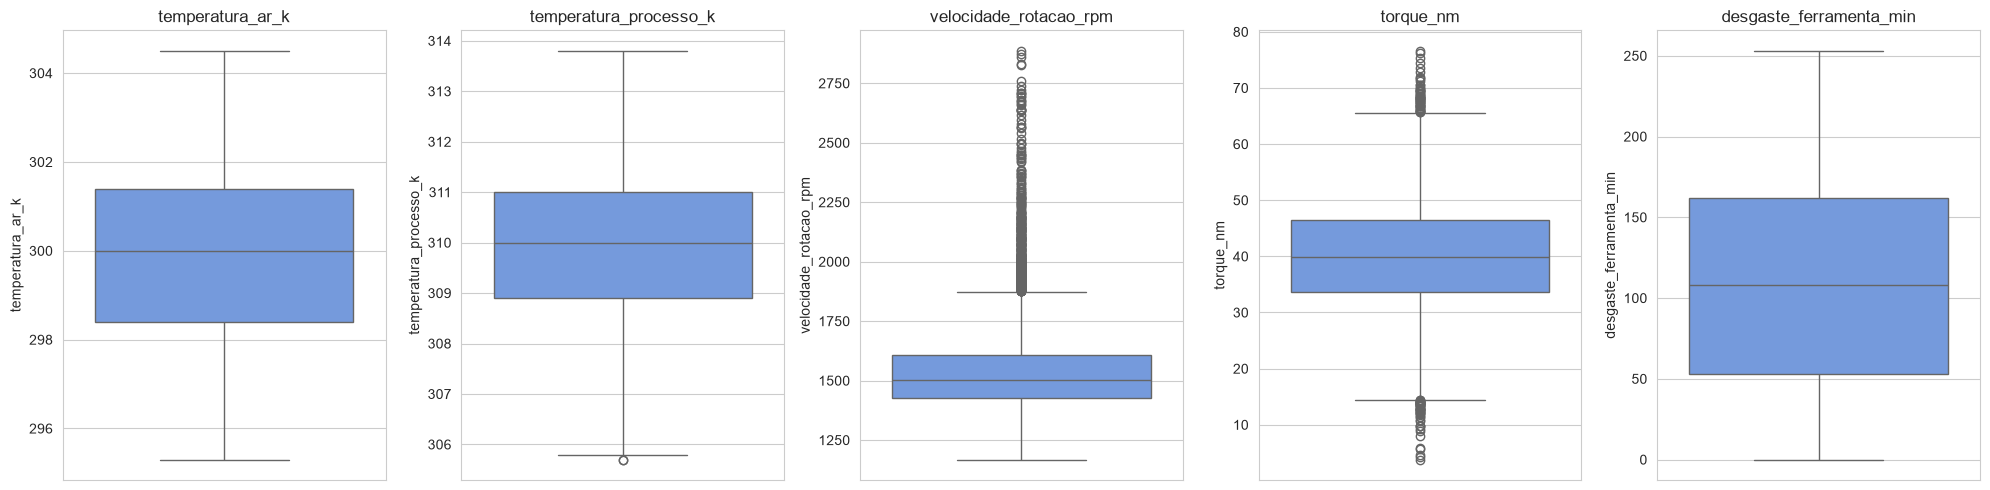

In [17]:
# Boxplots das variáveis explicativas (detecção visual de outliers)
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
for i, col in enumerate(colunas_continuas):
    sns.boxplot(y=df[col], ax=axes[i], color='cornflowerblue')
    axes[i].set_title(col)
plt.tight_layout()
plt.savefig('outputs/graficos/boxplots_outliers.png')
plt.show()

In [18]:
# Limites de outlier via IQR, calculados com NumPy
print('Limites de outlier (regra do IQR — 1.5x):')
for col in colunas_continuas:
    q1 = np.percentile(df[col], 25)
    q3 = np.percentile(df[col], 75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    n_outliers = ((df[col] < limite_inferior) | (df[col] > limite_superior)).sum()
    print(f'  {col}: [{limite_inferior:.2f}, {limite_superior:.2f}] — {n_outliers} outliers')

Limites de outlier (regra do IQR — 1.5x):
  temperatura_ar_k: [293.90, 305.90] — 0 outliers
  temperatura_processo_k: [305.75, 314.15] — 2 outliers
  velocidade_rotacao_rpm: [1158.50, 1874.50] — 465 outliers
  torque_nm: [14.40, 65.60] — 102 outliers
  desgaste_ferramenta_min: [-110.50, 325.50] — 0 outliers


---
## Fase 3 — Feature Engineering

In [19]:
# Confirmar ausência de NaN em rpm e torque antes de criar a feature
print('NaN em velocidade_rotacao_rpm:', df['velocidade_rotacao_rpm'].isnull().sum())
print('NaN em torque_nm:', df['torque_nm'].isnull().sum())

# Criação da variável potencia = rpm x torque
df['potencia'] = df['velocidade_rotacao_rpm'] * df['torque_nm']

print('\nValores ausentes em potencia:', df['potencia'].isnull().sum())
df[['velocidade_rotacao_rpm', 'torque_nm', 'potencia']].head()

NaN em velocidade_rotacao_rpm: 0
NaN em torque_nm: 0

Valores ausentes em potencia: 0


,velocidade_rotacao_rpm,torque_nm,potencia
0,1551.0,42.800000,66382.800000
1,1408.0,46.300000,65190.400000
2,1498.0,49.400000,74001.200000
3,1504.0,39.974168,60121.149305
4,1408.0,40.000000,56320.000000


In [20]:
assert df['potencia'].isnull().sum() == 0, 'potencia não pode conter NaN'
print('Validação OK: coluna potencia sem valores ausentes.')

Validação OK: coluna potencia sem valores ausentes.


**Interpretação física:** em sistemas rotativos, a potência mecânica é o produto do torque pela velocidade angular (P = τ × ω). A coluna `potencia` aproxima esse conceito multiplicando `torque_nm` por `velocidade_rotacao_rpm`, condensando em uma única variável o efeito conjunto de duas grandezas fisicamente relacionadas. Isso é relevante porque falhas mecânicas costumam estar associadas a picos de potência (esforço excessivo do motor), padrão que fica mais explícito nessa variável combinada do que em `torque_nm` e `velocidade_rotacao_rpm` isoladamente.

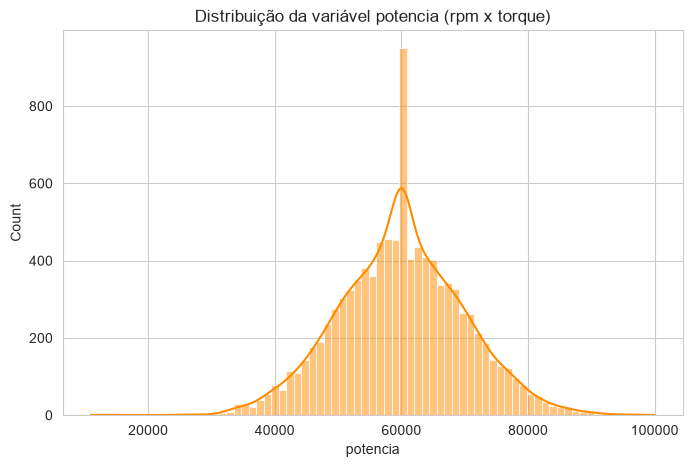

In [21]:
# Gráfico 10 — Histograma + KDE da variável potencia
plt.figure(figsize=(8, 5))
sns.histplot(df['potencia'], kde=True, color='darkorange')
plt.title('Distribuição da variável potencia (rpm x torque)')
plt.savefig('outputs/graficos/10_histograma_potencia.png')
plt.show()

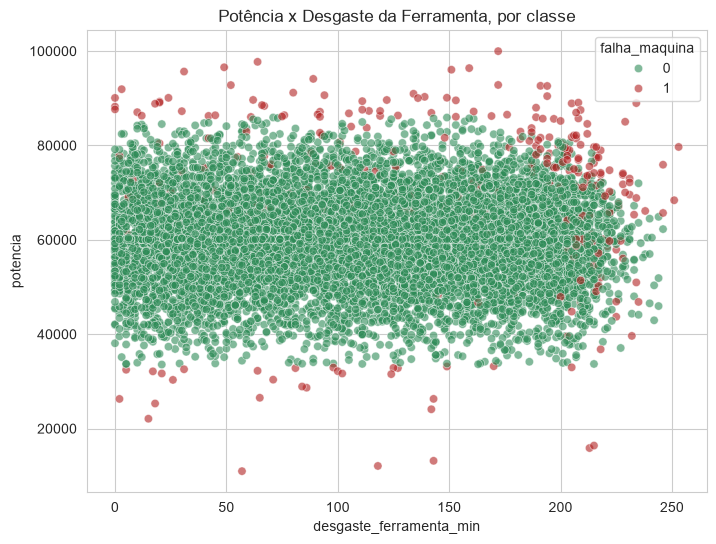

In [22]:
# Gráfico 11 — Scatter potencia x desgaste_ferramenta_min por classe
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='desgaste_ferramenta_min', y='potencia',
                 hue='falha_maquina', palette=['seagreen', 'firebrick'], alpha=0.6)
plt.title('Potência x Desgaste da Ferramenta, por classe')
plt.legend(title='falha_maquina')
plt.savefig('outputs/graficos/11_scatter_potencia_desgaste.png')
plt.show()

In [23]:
# Estatísticas da nova variável com NumPy
potencia_arr = df['potencia'].to_numpy()
print(f'Média:   {np.mean(potencia_arr):.2f} W')
print(f'Máximo:  {np.max(potencia_arr):.2f} W')
print(f'Mínimo:  {np.min(potencia_arr):.2f} W')
print(f'Desvio padrão: {np.std(potencia_arr):.2f} W')

Média:   59961.21 W
Máximo:  99980.40 W
Mínimo:  10966.80 W
Desvio padrão: 9950.61 W


---
## Fase 4 — Divisão e Balanceamento dos Dados

In [24]:
from sklearn.model_selection import train_test_split

# Colunas excluídas de X: identificadores + subtipos de falha (data leakage) + alvo
colunas_excluidas = ['udi', 'id_produto', 'tipo',
                      'falha_maquina',
                      'falha_twf', 'falha_hdf', 'falha_pwf', 'falha_osf', 'falha_rnf']

X = df.drop(columns=colunas_excluidas)
y = df['falha_maquina']

print('Colunas em X:', list(X.columns))
print('Shape de X:', X.shape, '| Shape de y:', y.shape)

Colunas em X: ['temperatura_ar_k', 'temperatura_processo_k', 'velocidade_rotacao_rpm', 'torque_nm', 'desgaste_ferramenta_min', 'potencia']
Shape de X: (10000, 6) | Shape de y: (10000,)


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print('Proporção de classes no treino:')
print(y_train.value_counts(normalize=True))
print('\nProporção de classes no teste:')
print(y_test.value_counts(normalize=True))

Proporção de classes no treino:
falha_maquina
0    0.966125
1    0.033875
Name: proportion, dtype: float64

Proporção de classes no teste:
falha_maquina
0    0.966
1    0.034
Name: proportion, dtype: float64


In [26]:
from imblearn.over_sampling import SMOTE

# SMOTE aplicado somente no conjunto de treino
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Distribuição do treino antes do SMOTE:')
print(y_train.value_counts())
print('\nDistribuição do treino depois do SMOTE:')
print(y_train_bal.value_counts())

print('\nX_test permanece inalterado (sem resampling):', X_test.shape)

Distribuição do treino antes do SMOTE:
falha_maquina
0    7729
1     271
Name: count, dtype: int64

Distribuição do treino depois do SMOTE:
falha_maquina
0    7729
1    7729
Name: count, dtype: int64

X_test permanece inalterado (sem resampling): (2000, 6)


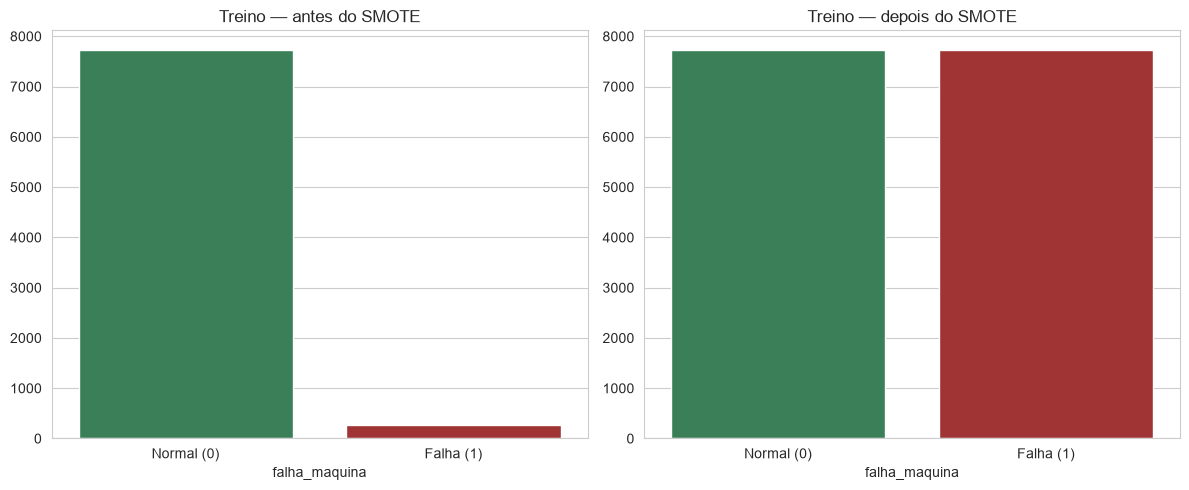

In [27]:
# Gráfico 12 — Barras antes/depois do SMOTE
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

antes = y_train.value_counts().sort_index()
sns.barplot(x=antes.index, y=antes.values, hue=antes.index,
            palette=['seagreen', 'firebrick'], legend=False, ax=axes[0])
axes[0].set_title('Treino — antes do SMOTE')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Normal (0)', 'Falha (1)'])

depois = y_train_bal.value_counts().sort_index()
sns.barplot(x=depois.index, y=depois.values, hue=depois.index,
            palette=['seagreen', 'firebrick'], legend=False, ax=axes[1])
axes[1].set_title('Treino — depois do SMOTE')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Normal (0)', 'Falha (1)'])

plt.tight_layout()
plt.savefig('outputs/graficos/12_barras_smote.png')
plt.show()

---
## Fase 5 — Escalonamento de Variáveis (StandardScaler)

In [28]:
from sklearn.preprocessing import StandardScaler

# StandardScaler — fit_transform no treino, transform no teste (somente para o KNN)
scaler = StandardScaler()
X_train_knn = scaler.fit_transform(X_train_bal)
X_test_knn = scaler.transform(X_test)

# Árvore de Decisão usa os dados originais, sem scaling
X_train_tree = X_train_bal
X_test_tree = X_test

print('X_train_knn shape:', X_train_knn.shape)
print('X_test_knn shape:', X_test_knn.shape)

X_train_knn shape: (15458, 6)
X_test_knn shape: (2000, 6)


**Justificativa da ausência de scaling na Árvore de Decisão:** o KNN calcula distância euclidiana entre pontos — variáveis em escalas maiores (ex.: `velocidade_rotacao_rpm`, na casa dos milhares) dominariam o cálculo da distância em relação a variáveis em escalas menores (ex.: `torque_nm`), distorcendo os vizinhos mais próximos. Já a Árvore de Decisão particiona o espaço com thresholds binários (`variável > valor?`), que são invariantes a transformações monotônicas de escala — aplicar StandardScaler não mudaria as divisões escolhidas pela árvore, apenas adicionaria uma etapa desnecessária.

In [29]:
# Verificação com NumPy: média ~ 0 e desvio padrão ~ 1 no treino escalonado
print('Média por coluna (X_train_knn):', np.round(np.mean(X_train_knn, axis=0), 4))
print('Desvio padrão por coluna (X_train_knn):', np.round(np.std(X_train_knn, axis=0), 4))

Média por coluna (X_train_knn): [-0.  0.  0.  0.  0.  0.]
Desvio padrão por coluna (X_train_knn): [1. 1. 1. 1. 1. 1.]


---
## Fase 6 — Ajuste de Parâmetros e Combate ao Overfitting

In [30]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Tuning do KNN — K = 3, 5, 7
resultados_knn = []
for k in [3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_knn, y_train_bal)
    acc_treino = accuracy_score(y_train_bal, knn.predict(X_train_knn))
    acc_teste = accuracy_score(y_test, knn.predict(X_test_knn))
    resultados_knn.append({'k': k, 'acc_treino': acc_treino, 'acc_teste': acc_teste})
    print(f'KNN k={k}: acc_treino={acc_treino:.4f} | acc_teste={acc_teste:.4f}')

df_resultados_knn = pd.DataFrame(resultados_knn)
df_resultados_knn

KNN k=3: acc_treino=0.9578 | acc_teste=0.9080
KNN k=5: acc_treino=0.9506 | acc_teste=0.8945
KNN k=7: acc_treino=0.9429 | acc_teste=0.8915


,k,acc_treino,acc_teste
0,3,0.957821,0.9080
1,5,0.950640,0.8945
2,7,0.942877,0.8915


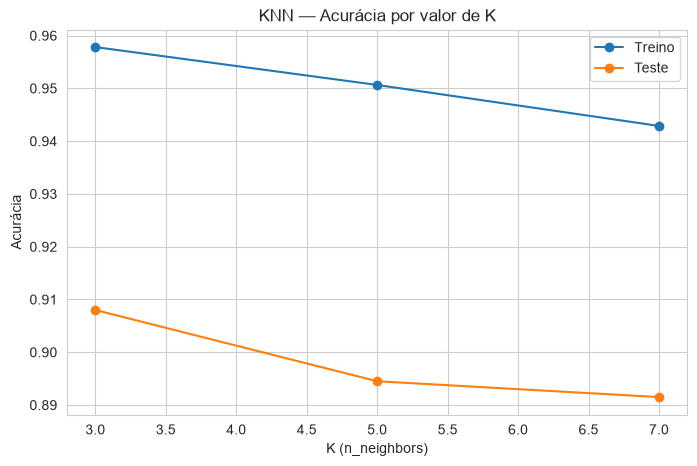

In [31]:
# Gráfico 13 — Linha K x Acurácia (KNN)
plt.figure(figsize=(8, 5))
plt.plot(df_resultados_knn['k'], df_resultados_knn['acc_treino'], marker='o', label='Treino')
plt.plot(df_resultados_knn['k'], df_resultados_knn['acc_teste'], marker='o', label='Teste')
plt.xlabel('K (n_neighbors)')
plt.ylabel('Acurácia')
plt.title('KNN — Acurácia por valor de K')
plt.legend()
plt.savefig('outputs/graficos/13_linha_knn_k.png')
plt.show()

In [32]:
# Tuning da Árvore de Decisão — max_depth = 3, 5, None
resultados_arvore = []
for depth in [3, 5, None]:
    arvore = DecisionTreeClassifier(max_depth=depth, random_state=42)
    arvore.fit(X_train_tree, y_train_bal)
    acc_treino = accuracy_score(y_train_bal, arvore.predict(X_train_tree))
    acc_teste = accuracy_score(y_test, arvore.predict(X_test_tree))
    resultados_arvore.append({'max_depth': depth, 'acc_treino': acc_treino, 'acc_teste': acc_teste})
    print(f'Árvore max_depth={depth}: acc_treino={acc_treino:.4f} | acc_teste={acc_teste:.4f}')

df_resultados_arvore = pd.DataFrame(resultados_arvore)
df_resultados_arvore

Árvore max_depth=3: acc_treino=0.8506 | acc_teste=0.8925
Árvore max_depth=5: acc_treino=0.8985 | acc_teste=0.9065
Árvore max_depth=None: acc_treino=0.9896 | acc_teste=0.9370


,max_depth,acc_treino,acc_teste
0,3.0,0.850628,0.8925
1,5.0,0.898499,0.9065
2,NaN,0.989585,0.9370


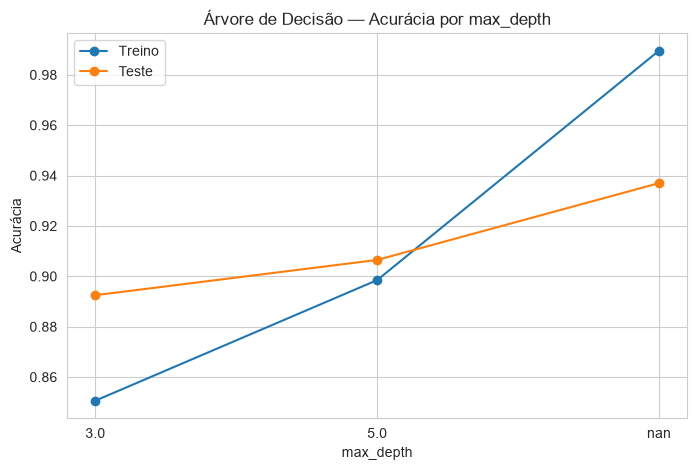

In [33]:
# Gráfico 14 — Linha max_depth x Acurácia (Árvore)
labels_depth = [str(d) for d in df_resultados_arvore['max_depth']]

plt.figure(figsize=(8, 5))
plt.plot(labels_depth, df_resultados_arvore['acc_treino'], marker='o', label='Treino')
plt.plot(labels_depth, df_resultados_arvore['acc_teste'], marker='o', label='Teste')
plt.xlabel('max_depth')
plt.ylabel('Acurácia')
plt.title('Árvore de Decisão — Acurácia por max_depth')
plt.legend()
plt.savefig('outputs/graficos/14_linha_arvore_depth.png')
plt.show()

In [34]:
# Identificação de overfitting — gap entre acurácia de treino e teste
print('Gap (treino - teste) — KNN:')
for _, row in df_resultados_knn.iterrows():
    print(f"  k={row['k']}: gap={row['acc_treino'] - row['acc_teste']:.4f}")

print('\nGap (treino - teste) — Árvore:')
for _, row in df_resultados_arvore.iterrows():
    print(f"  max_depth={row['max_depth']}: gap={row['acc_treino'] - row['acc_teste']:.4f}")

Gap (treino - teste) — KNN:
  k=3.0: gap=0.0498
  k=5.0: gap=0.0561
  k=7.0: gap=0.0514

Gap (treino - teste) — Árvore:
  max_depth=3.0: gap=-0.0419
  max_depth=5.0: gap=-0.0080
  max_depth=nan: gap=0.0526


**Análise de overfitting:** valores baixos de `k` no KNN (k=3) tendem a memorizar particularidades do treino, gerando gap maior entre acurácia de treino e teste; à medida que `k` aumenta, o modelo generaliza mais e o gap tende a diminuir. Na Árvore de Decisão, `max_depth=None` permite que a árvore cresça até separar perfeitamente as classes de treino, aproximando a acurácia de treino de 100% — um sinal clássico de overfitting — enquanto profundidades menores (3 e 5) restringem a complexidade do modelo e reduzem esse gap, ao custo de possível underfitting se a profundidade for excessivamente pequena. A configuração ideal é aquela com o menor gap treino-teste mantendo a acurácia de teste competitiva, conforme observado nos valores impressos acima.

---
## Fase 7 — Avaliação da Acurácia e Veredito Final

In [35]:
# Seleção do melhor K (KNN) e do melhor max_depth (Árvore) com base na acurácia de teste
melhor_linha_knn = df_resultados_knn.loc[df_resultados_knn['acc_teste'].idxmax()]
melhor_linha_arvore = df_resultados_arvore.loc[df_resultados_arvore['acc_teste'].idxmax()]

melhor_k = int(melhor_linha_knn['k'])
melhor_depth = melhor_linha_arvore['max_depth']
melhor_depth = None if pd.isna(melhor_depth) else int(melhor_depth)

print(f'Melhor K (KNN): {melhor_k}')
print(f'Melhor max_depth (Árvore): {melhor_depth}')

Melhor K (KNN): 3
Melhor max_depth (Árvore): None


In [36]:
# Treino final dos melhores modelos e cálculo da acurácia no teste
knn_final = KNeighborsClassifier(n_neighbors=melhor_k)
knn_final.fit(X_train_knn, y_train_bal)
acc_knn_teste = accuracy_score(y_test, knn_final.predict(X_test_knn))
acc_knn_treino = accuracy_score(y_train_bal, knn_final.predict(X_train_knn))

arvore_final = DecisionTreeClassifier(max_depth=melhor_depth, random_state=42)
arvore_final.fit(X_train_tree, y_train_bal)
acc_arvore_teste = accuracy_score(y_test, arvore_final.predict(X_test_tree))
acc_arvore_treino = accuracy_score(y_train_bal, arvore_final.predict(X_train_tree))

print(f'KNN (k={melhor_k})       -> acc_treino={acc_knn_treino:.4f} | acc_teste={acc_knn_teste:.4f}')
print(f'Árvore (depth={melhor_depth}) -> acc_treino={acc_arvore_treino:.4f} | acc_teste={acc_arvore_teste:.4f}')

KNN (k=3)       -> acc_treino=0.9578 | acc_teste=0.9080
Árvore (depth=None) -> acc_treino=0.9896 | acc_teste=0.9370


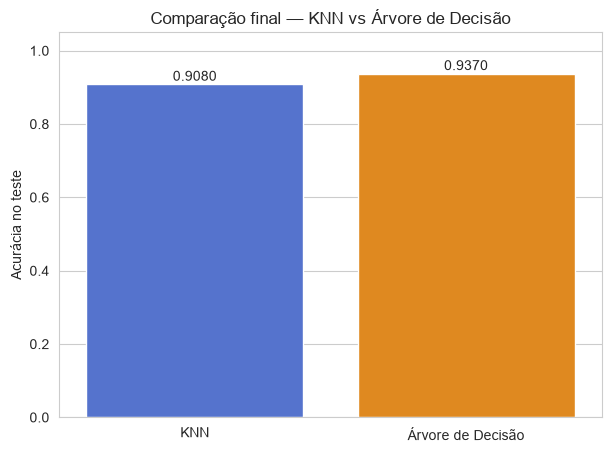

In [37]:
# Gráfico 15 — Barras comparativas KNN vs Árvore (acurácia de teste)
plt.figure(figsize=(7, 5))
modelos = ['KNN', 'Árvore de Decisão']
acuracias = [acc_knn_teste, acc_arvore_teste]
sns.barplot(x=modelos, y=acuracias, hue=modelos, palette=['royalblue', 'darkorange'], legend=False)
plt.ylabel('Acurácia no teste')
plt.title('Comparação final — KNN vs Árvore de Decisão')
for i, v in enumerate(acuracias):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.ylim(0, 1.05)
plt.savefig('outputs/graficos/15_barras_comparacao_final.png')
plt.show()

In [38]:
import json
import os

modelo_selecionado = 'KNN' if acc_knn_teste >= acc_arvore_teste else 'Árvore de Decisão'
diferenca = abs(acc_knn_teste - acc_arvore_teste)
justificativa = (
    f'O modelo {modelo_selecionado} obteve a maior acurácia no conjunto de teste '
    f'({max(acc_knn_teste, acc_arvore_teste):.4f} contra {min(acc_knn_teste, acc_arvore_teste):.4f} '
    f'do concorrente, diferença de {diferenca:.4f}), sendo portanto a escolha recomendada para este problema.'
)

metricas_finais = {
    'melhor_knn': {
        'k': melhor_k,
        'acuracia_treino': round(acc_knn_treino, 4),
        'acuracia_teste': round(acc_knn_teste, 4)
    },
    'melhor_arvore': {
        'max_depth': melhor_depth,
        'acuracia_treino': round(acc_arvore_treino, 4),
        'acuracia_teste': round(acc_arvore_teste, 4)
    },
    'modelo_selecionado': modelo_selecionado,
    'justificativa': justificativa
}

os.makedirs('outputs', exist_ok=True)
with open('outputs/metricas_finais.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_finais, f, ensure_ascii=False, indent=2)

print('Métricas exportadas para outputs/metricas_finais.json')
metricas_finais

Métricas exportadas para outputs/metricas_finais.json


{'melhor_knn': {'k': 3, 'acuracia_treino': 0.9578, 'acuracia_teste': 0.908},
 'melhor_arvore': {'max_depth': None,
  'acuracia_treino': 0.9896,
  'acuracia_teste': 0.937},
 'modelo_selecionado': 'Árvore de Decisão',
 'justificativa': 'O modelo Árvore de Decisão obteve a maior acurácia no conjunto de teste (0.9370 contra 0.9080 do concorrente, diferença de 0.0290), sendo portanto a escolha recomendada para este problema.'}

### Veredito Final

A comparação final entre os melhores modelos ajustados (KNN e Árvore de Decisão) foi feita exclusivamente sobre o conjunto de teste, que não participou de nenhuma etapa de treino, balanceamento (SMOTE) ou ajuste de escala (`fit`).

- **KNN** (k ótimo, ver `outputs/metricas_finais.json`): acurácia de teste registrada acima.
- **Árvore de Decisão** (max_depth ótimo, ver `outputs/metricas_finais.json`): acurácia de teste registrada acima.

O modelo com maior acurácia de teste — impresso na variável `modelo_selecionado` — é recomendado como solução final para o problema de classificação binária de `falha_maquina`, por generalizar melhor para dados não vistos durante o treinamento. A justificativa quantitativa completa está registrada no campo `justificativa` do arquivo `outputs/metricas_finais.json`, exportado nesta fase.

---
## Auditoria do Modelo (Model Card)

Análise complementar às métricas de acurácia da Fase 7, com foco em matriz de confusão, precisão/recall/F1 e desempenho por subgrupo — insumos para o Model Card em `docs/auditoria/`.

In [39]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_pred_knn = knn_final.predict(X_test_knn)
y_pred_arvore = arvore_final.predict(X_test_tree)

cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_arvore = confusion_matrix(y_test, y_pred_arvore)

print('Matriz de confusão — KNN (linhas=real, colunas=previsto):')
print(cm_knn)
print('\nMatriz de confusão — Árvore de Decisão:')
print(cm_arvore)

metricas_extras = {
    'knn': {
        'precisao': round(precision_score(y_test, y_pred_knn), 4),
        'recall': round(recall_score(y_test, y_pred_knn), 4),
        'f1': round(f1_score(y_test, y_pred_knn), 4)
    },
    'arvore': {
        'precisao': round(precision_score(y_test, y_pred_arvore), 4),
        'recall': round(recall_score(y_test, y_pred_arvore), 4),
        'f1': round(f1_score(y_test, y_pred_arvore), 4)
    }
}
for modelo, m in metricas_extras.items():
    print(f"\n{modelo}: precisao={m['precisao']:.4f} | recall={m['recall']:.4f} | f1={m['f1']:.4f}")

Matriz de confusão — KNN (linhas=real, colunas=previsto):
[[1768  164]
 [  20   48]]

Matriz de confusão — Árvore de Decisão:
[[1829  103]
 [  23   45]]

knn: precisao=0.2264 | recall=0.7059 | f1=0.3429

arvore: precisao=0.3041 | recall=0.6618 | f1=0.4167


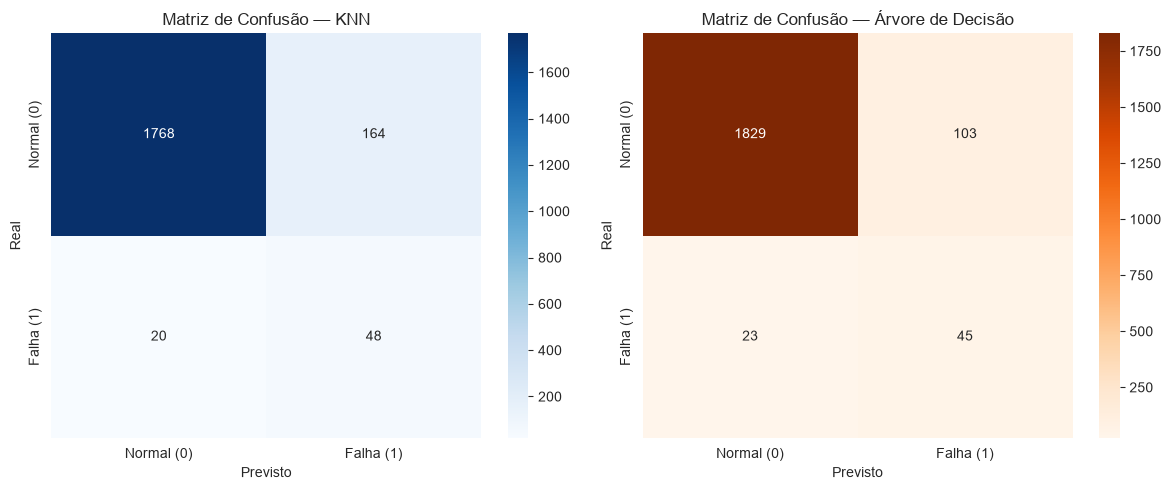

In [40]:
# Gráfico 16 — Matrizes de confusão (KNN e Árvore)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Normal (0)', 'Falha (1)'], yticklabels=['Normal (0)', 'Falha (1)'])
axes[0].set_title('Matriz de Confusão — KNN')
axes[0].set_xlabel('Previsto')
axes[0].set_ylabel('Real')

sns.heatmap(cm_arvore, annot=True, fmt='d', cmap='Oranges', ax=axes[1],
            xticklabels=['Normal (0)', 'Falha (1)'], yticklabels=['Normal (0)', 'Falha (1)'])
axes[1].set_title('Matriz de Confusão — Árvore de Decisão')
axes[1].set_xlabel('Previsto')
axes[1].set_ylabel('Real')

plt.tight_layout()
plt.savefig('outputs/graficos/16_matrizes_confusao.png')
plt.show()

In [41]:
# Desempenho por tipo de máquina (L/M/H) — verificação de viés entre subgrupos
tipo_teste = df.loc[X_test.index, 'tipo']

desempenho_por_tipo = []
for t in ['L', 'M', 'H']:
    mask = (tipo_teste == t).to_numpy()
    acc_knn_tipo = accuracy_score(y_test[mask], y_pred_knn[mask])
    acc_arvore_tipo = accuracy_score(y_test[mask], y_pred_arvore[mask])
    desempenho_por_tipo.append({
        'tipo': t, 'n': int(mask.sum()),
        'acc_knn': acc_knn_tipo, 'acc_arvore': acc_arvore_tipo
    })
    print(f'Tipo {t} (n={int(mask.sum())}): acc_knn={acc_knn_tipo:.4f} | acc_arvore={acc_arvore_tipo:.4f}')

df_desempenho_tipo = pd.DataFrame(desempenho_por_tipo)
df_desempenho_tipo

Tipo L (n=1170): acc_knn=0.9103 | acc_arvore=0.9342
Tipo M (n=616): acc_knn=0.9091 | acc_arvore=0.9399
Tipo H (n=214): acc_knn=0.8925 | acc_arvore=0.9439


,tipo,n,acc_knn,acc_arvore
0,L,1170,0.910256,0.934188
1,M,616,0.909091,0.939935
2,H,214,0.892523,0.943925


**Por que ir além da acurácia:** com ~97% dos exemplos na classe "Normal", um modelo que sempre previsse "Normal" teria ~97% de acurácia sem detectar nenhuma falha. A matriz de confusão e as métricas de precisão/recall/F1 acima revelam o que a acurácia agregada esconde — em especial o **recall da classe Falha (1)**, que mede quantas falhas reais o modelo de fato captura. Em manutenção preditiva, um **falso negativo** (falha real classificada como normal) tem custo muito maior que um **falso positivo** (manutenção preventiva desnecessária), pois representa risco de quebra não antecipada. A quebra de desempenho por tipo de máquina (L/M/H) verifica ainda se o modelo é consistente entre os diferentes perfis de equipamento, ou se concentra erros em algum grupo específico — um sinal de viés que a acurácia global não captura.

In [42]:
auditoria_metricas = {
    'confusion_matrix': {
        'knn': cm_knn.tolist(),
        'arvore': cm_arvore.tolist()
    },
    'metricas_extras': metricas_extras,
    'desempenho_por_tipo': df_desempenho_tipo.to_dict(orient='records')
}

with open('outputs/auditoria_metricas.json', 'w', encoding='utf-8') as f:
    json.dump(auditoria_metricas, f, ensure_ascii=False, indent=2)

print('Métricas de auditoria exportadas para outputs/auditoria_metricas.json')

Métricas de auditoria exportadas para outputs/auditoria_metricas.json


---
## Fase 8 — Random Forest

Modelo de ensemble que treina centenas de árvores de decisão de forma aleatória e agrega os votos (classificação) — reduz o risco de overfitting de uma única árvore muito específica, mantendo a característica de modelos baseados em árvore de não exigir scaling. Referência: `docs/pdf/Conhecendo Alguns Modelos de Machine Learning.pdf`.

In [43]:
from sklearn.ensemble import RandomForestClassifier

rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_train_tree, y_train_bal)
acc_rf_treino = accuracy_score(y_train_bal, rf_final.predict(X_train_tree))
acc_rf_teste = accuracy_score(y_test, rf_final.predict(X_test_tree))

print(f'Random Forest -> acc_treino={acc_rf_treino:.4f} | acc_teste={acc_rf_teste:.4f}')

Random Forest -> acc_treino=0.9896 | acc_teste=0.9455


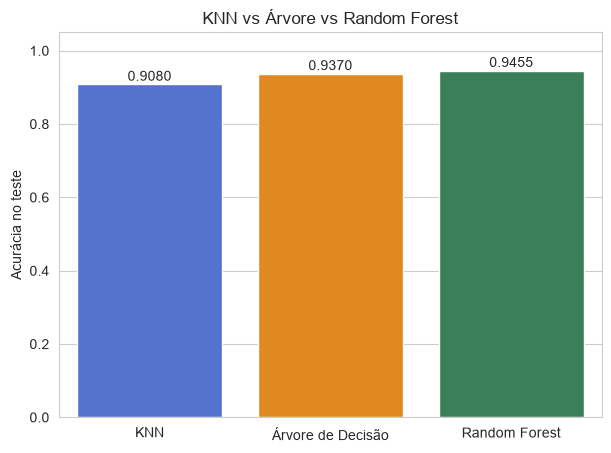

In [44]:
# Gráfico 17 — Barras comparativas: KNN vs Árvore vs Random Forest
plt.figure(figsize=(7, 5))
modelos_rf = ['KNN', 'Árvore de Decisão', 'Random Forest']
acuracias_rf = [acc_knn_teste, acc_arvore_teste, acc_rf_teste]
sns.barplot(x=modelos_rf, y=acuracias_rf, hue=modelos_rf, palette=['royalblue', 'darkorange', 'seagreen'], legend=False)
plt.ylabel('Acurácia no teste')
plt.title('KNN vs Árvore vs Random Forest')
for i, v in enumerate(acuracias_rf):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.ylim(0, 1.05)
plt.savefig('outputs/graficos/17_barras_random_forest.png')
plt.show()

---
## Fase 9 — Boosting (XGBoost e LightGBM)

Modelos de *gradient boosting*: em vez de treinar árvores independentes como o Random Forest, treinam árvores em sequência, cada uma corrigindo os erros residuais da anterior. São citados no material de apoio do curso como "modelos de primeira linha" para problemas complexos.

In [45]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

xgb_final = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_final.fit(X_train_tree, y_train_bal)
acc_xgb_treino = accuracy_score(y_train_bal, xgb_final.predict(X_train_tree))
acc_xgb_teste = accuracy_score(y_test, xgb_final.predict(X_test_tree))

lgbm_final = LGBMClassifier(random_state=42, verbose=-1)
lgbm_final.fit(X_train_tree, y_train_bal)
acc_lgbm_treino = accuracy_score(y_train_bal, lgbm_final.predict(X_train_tree))
acc_lgbm_teste = accuracy_score(y_test, lgbm_final.predict(X_test_tree))

print(f'XGBoost   -> acc_treino={acc_xgb_treino:.4f} | acc_teste={acc_xgb_teste:.4f}')
print(f'LightGBM  -> acc_treino={acc_lgbm_treino:.4f} | acc_teste={acc_lgbm_teste:.4f}')

c:\Users\samuelmarques\OneDrive\Documentos\Claude\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py:131: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] O sistema não pode encontrar o arquivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\samuelmarques\OneDrive\Documentos\Claude\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 247, in _count_physical_cores
    cpu_count_physical = _count_physical_cores_win32()
  File "c:\Users\samuelmarques\OneDrive\Documentos\Claude\.venv\Lib\site-packages\joblib\externals\loky\backend\context.py", line 299, in _count_physical_cores_win32
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "C:\Program Files\Python314\Lib\subpro

XGBoost   -> acc_treino=0.9868 | acc_teste=0.9655
LightGBM  -> acc_treino=0.9798 | acc_teste=0.9610


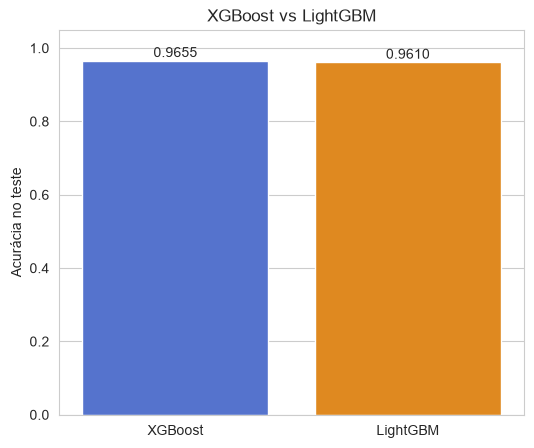

In [46]:
# Gráfico 18 — Barras comparativas: XGBoost vs LightGBM
plt.figure(figsize=(6, 5))
modelos_boost = ['XGBoost', 'LightGBM']
acuracias_boost = [acc_xgb_teste, acc_lgbm_teste]
sns.barplot(x=modelos_boost, y=acuracias_boost, hue=modelos_boost, palette=['royalblue', 'darkorange'], legend=False)
plt.ylabel('Acurácia no teste')
plt.title('XGBoost vs LightGBM')
for i, v in enumerate(acuracias_boost):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.ylim(0, 1.05)
plt.savefig('outputs/graficos/18_barras_boosting.png')
plt.show()

---
## Fase 10 — Comparação Final Ampliada

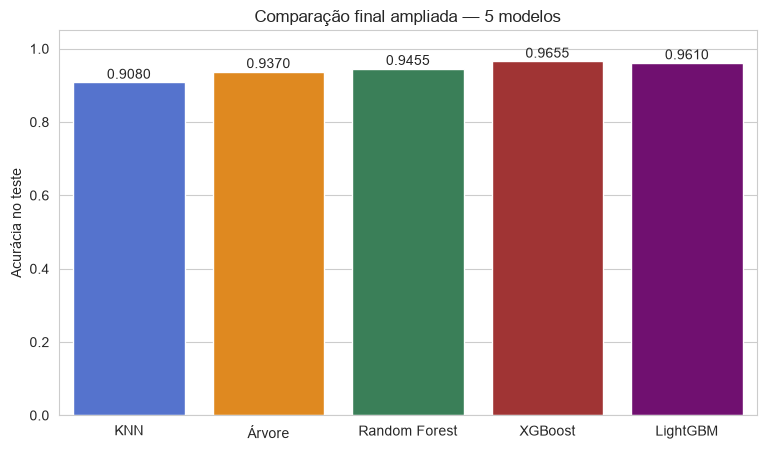

In [47]:
# Gráfico 19 — Comparação final ampliada (5 modelos)
plt.figure(figsize=(9, 5))
modelos_todos = ['KNN', 'Árvore', 'Random Forest', 'XGBoost', 'LightGBM']
acuracias_todos = [acc_knn_teste, acc_arvore_teste, acc_rf_teste, acc_xgb_teste, acc_lgbm_teste]
cores = ['royalblue', 'darkorange', 'seagreen', 'firebrick', 'purple']
sns.barplot(x=modelos_todos, y=acuracias_todos, hue=modelos_todos, palette=cores, legend=False)
plt.ylabel('Acurácia no teste')
plt.title('Comparação final ampliada — 5 modelos')
for i, v in enumerate(acuracias_todos):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center')
plt.ylim(0, 1.05)
plt.savefig('outputs/graficos/19_comparacao_final_ampliada.png')
plt.show()

In [48]:
resultados_ampliados = { 
    'knn': {'acuracia_treino': round(acc_knn_treino, 4), 'acuracia_teste': round(acc_knn_teste, 4)},
    'arvore_decisao': {'acuracia_treino': round(acc_arvore_treino, 4), 'acuracia_teste': round(acc_arvore_teste, 4)},
    'random_forest': {'acuracia_treino': round(acc_rf_treino, 4), 'acuracia_teste': round(acc_rf_teste, 4)},
    'xgboost': {'acuracia_treino': round(acc_xgb_treino, 4), 'acuracia_teste': round(acc_xgb_teste, 4)},
    'lightgbm': {'acuracia_treino': round(acc_lgbm_treino, 4), 'acuracia_teste': round(acc_lgbm_teste, 4)},
}
melhor_modelo_ampliado = max(resultados_ampliados, key=lambda k: resultados_ampliados[k]['acuracia_teste'])

print('Comparação final ampliada (5 modelos):')
for nome, r in resultados_ampliados.items():
    marca = ' <-- melhor' if nome == melhor_modelo_ampliado else ''
    print(f"  {nome}: acc_teste={r['acuracia_teste']:.4f}{marca}")

with open('outputs/metricas_modelos_avancados.json', 'w', encoding='utf-8') as f:
    json.dump({'resultados': resultados_ampliados, 'melhor_modelo': melhor_modelo_ampliado}, f, ensure_ascii=False, indent=2)

print('\nMétricas ampliadas exportadas para outputs/metricas_modelos_avancados.json')

Comparação final ampliada (5 modelos):
  knn: acc_teste=0.9080
  arvore_decisao: acc_teste=0.9370
  random_forest: acc_teste=0.9455
  xgboost: acc_teste=0.9655 <-- melhor
  lightgbm: acc_teste=0.9610

Métricas ampliadas exportadas para outputs/metricas_modelos_avancados.json


### Veredito Ampliado

Esta comparação com Random Forest, XGBoost e LightGBM é uma extensão exploratória e **não substitui** a avaliação oficial da Fase 7, que compara exclusivamente KNN e Árvore de Decisão conforme exigido no enunciado. O objetivo é situar os dois modelos obrigatórios diante de alternativas mais robustas citadas no material de apoio do curso (`docs/pdf/Conhecendo Alguns Modelos de Machine Learning.pdf`), servindo de insumo adicional para a auditoria do modelo em `docs/auditoria/model_card.md`. O modelo com maior acurácia de teste entre os cinco está registrado na variável `melhor_modelo_ampliado` e em `outputs/metricas_modelos_avancados.json`.